# Task 1A Preprocessing - Instacart Hybrid Recommendation System

Preprocesses the Instacart dataset and produces all artefacts needed by the hybrid recommendation system: a user-item matrix, TF-IDF content matrix, user content profiles, a NearestNeighbors model, and a global popularity index. All outputs are written to Google Drive.

## Google Drive Setup

In [1]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive so all project files are accessible at /content/drive.
drive.mount('/content/drive')

# Update this path to match the location of the project root on your Google Drive.
DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

# Path to the raw Instacart CSV files.
RAW_DIR         = DRIVE_ROOT / 'data' / 'Task 1' / 'raw' / 'InstaCart Dataset'
# Directory where all preprocessed output files will be written.
OUTPUT_DIR      = DRIVE_ROOT / 'data' / 'Task 1' / 'processed'
# File used to record how far the pipeline has progressed.
CHECKPOINT_PATH = OUTPUT_DIR / 'preprocessing_checkpoint.json'

# Create the output directory if it does not yet exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DRIVE_ROOT      :', DRIVE_ROOT)
print('RAW_DIR         :', RAW_DIR)
print('OUTPUT_DIR      :', OUTPUT_DIR)
print('CHECKPOINT_PATH :', CHECKPOINT_PATH)

Mounted at /content/drive
DRIVE_ROOT      : /content/drive/MyDrive/Advanced AI/advanced-ai
RAW_DIR         : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/raw/InstaCart Dataset
OUTPUT_DIR      : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/processed
CHECKPOINT_PATH : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/processed/preprocessing_checkpoint.json


## Section 1 - Imports and Configuration

Defines all imports and configuration constants, including filtering thresholds, TF-IDF parameters, and the custom stop word set. Colour words and generic size qualifiers are excluded; terms with food-specific meaning such as 'organic' and 'whole' are kept.

In [2]:
import os
import json
import shutil
import datetime
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import joblib

# Users with fewer than this many prior orders are excluded.
MIN_USER_ORDERS       = 5
# Products purchased fewer than this many times across all users are excluded.
MIN_PRODUCT_PURCHASES = 10
# Include both single words and two-word phrases in the TF-IDF vocabulary.
TFIDF_NGRAM_RANGE     = (1, 2)
# Distance metric for the NearestNeighbors model.
KNN_METRIC            = 'cosine'
# Brute-force is faster than tree methods at tens of thousands of dimensions.
KNN_ALGORITHM         = 'brute'
# Use all available CPU cores for neighbour lookups.
KNN_N_JOBS            = -1
RANDOM_SEED           = 42

# Department names to remove from the product catalogue before building recommendations.
NON_FOOD_DEPARTMENTS = {
    'personal care', 'household', 'babies', 'pets', 'missing', 'other', 'alcohol'
}

# Colour words that appear in product names but carry no food-specific meaning.
COLOUR_STOPWORDS = {
    'red', 'white', 'green', 'dark', 'black', 'orange', 'yellow',
    'blue', 'pink', 'gold', 'purple', 'silver', 'brown', 'light'
}

# Generic size/intensity qualifiers with little discriminative value.
QUALIFIER_STOPWORDS = {'mini', 'extra', 'super', 'ultra'}

# 'organic', 'natural', 'fresh', 'whole', 'free', 'low' are intentionally
# excluded from this list because they carry meaningful information for a
# food marketplace and improve content-based similarity quality.
CUSTOM_STOPWORDS = COLOUR_STOPWORDS | QUALIFIER_STOPWORDS

print('MIN_USER_ORDERS       :', MIN_USER_ORDERS)
print('MIN_PRODUCT_PURCHASES :', MIN_PRODUCT_PURCHASES)
print('TFIDF_NGRAM_RANGE     :', TFIDF_NGRAM_RANGE)
print('KNN_METRIC            :', KNN_METRIC)
print('KNN_ALGORITHM         :', KNN_ALGORITHM)
print('KNN_N_JOBS            :', KNN_N_JOBS)
print('RANDOM_SEED           :', RANDOM_SEED)
print()
print('NON_FOOD_DEPARTMENTS  :', sorted(NON_FOOD_DEPARTMENTS))
print('COLOUR_STOPWORDS      :', sorted(COLOUR_STOPWORDS))
print('QUALIFIER_STOPWORDS   :', sorted(QUALIFIER_STOPWORDS))
print('CUSTOM_STOPWORDS size :', len(CUSTOM_STOPWORDS))

MIN_USER_ORDERS       : 5
MIN_PRODUCT_PURCHASES : 10
TFIDF_NGRAM_RANGE     : (1, 2)
KNN_METRIC            : cosine
KNN_ALGORITHM         : brute
KNN_N_JOBS            : -1
RANDOM_SEED           : 42

NON_FOOD_DEPARTMENTS  : ['alcohol', 'babies', 'household', 'missing', 'other', 'personal care', 'pets']
COLOUR_STOPWORDS      : ['black', 'blue', 'brown', 'dark', 'gold', 'green', 'light', 'orange', 'pink', 'purple', 'red', 'silver', 'white', 'yellow']
QUALIFIER_STOPWORDS   : ['extra', 'mini', 'super', 'ultra']
CUSTOM_STOPWORDS size : 18


## Section 2 - Load Raw CSV Files

Loads all six source CSV files and raises an error immediately if any are missing. `low_memory=False` ensures dtype inference runs across the full file rather than per-chunk.

In [3]:
# Names of the six source CSV files.
csv_names = [
    'aisles.csv',
    'departments.csv',
    'orders.csv',
    'order_products__prior.csv',
    'order_products__train.csv',
    'products.csv',
]

# Raise an error immediately if any file is missing rather than letting it surface later.
for fname in csv_names:
    if not (RAW_DIR / fname).exists():
        raise FileNotFoundError(
            f'Required file not found: {RAW_DIR / fname}\n'
            'Confirm that DRIVE_ROOT is set correctly and the dataset has been uploaded.'
        )

# Read each file in full; low_memory=False ensures correct dtype inference.
aisles      = pd.read_csv(RAW_DIR / 'aisles.csv',               low_memory=False)
departments = pd.read_csv(RAW_DIR / 'departments.csv',           low_memory=False)
orders      = pd.read_csv(RAW_DIR / 'orders.csv',                low_memory=False)
order_prior = pd.read_csv(RAW_DIR / 'order_products__prior.csv', low_memory=False)
order_train = pd.read_csv(RAW_DIR / 'order_products__train.csv', low_memory=False)
products    = pd.read_csv(RAW_DIR / 'products.csv',              low_memory=False)

# Print shape and column list for each file to confirm successful loading.
for name, df in [
    ('aisles',      aisles),
    ('departments', departments),
    ('orders',      orders),
    ('order_prior', order_prior),
    ('order_train', order_train),
    ('products',    products),
]:
    print(f'{name:<15} shape={str(df.shape):<20} columns={list(df.columns)}')

aisles          shape=(134, 2)             columns=['aisle_id', 'aisle']
departments     shape=(21, 2)              columns=['department_id', 'department']
orders          shape=(3421083, 7)         columns=['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
order_prior     shape=(32434489, 4)        columns=['order_id', 'product_id', 'add_to_cart_order', 'reordered']
order_train     shape=(1384617, 4)         columns=['order_id', 'product_id', 'add_to_cart_order', 'reordered']
products        shape=(49688, 4)           columns=['product_id', 'product_name', 'aisle_id', 'department_id']


## Section 3 - Checkpointing Logic

Defines the checkpointing helper functions. Each checkpoint write is atomic — data is written to a `.tmp` file then renamed — so a crash cannot produce a partially-written checkpoint. Completed stages are skipped on restart.

In [4]:
# Ordered list of pipeline stages; index position defines progress ordering.
CHECKPOINT_STAGES = ['filtered', 'matrix_built', 'tfidf_built', 'knn_fitted', 'complete']

def stage_index(stage):
    return CHECKPOINT_STAGES.index(stage)

def past_stage(current, target):
    # Return True if current stage is strictly after target stage.
    if current is None:
        return False
    return stage_index(current) > stage_index(target)

def reached_stage(current, target):
    # Return True if current stage is at or past target stage.
    if current is None:
        return False
    return stage_index(current) >= stage_index(target)

def save_checkpoint(stage, extra=None):
    # Write the current pipeline stage to a JSON file.
    # Uses a write-to-temp-then-rename pattern so a crash during the write
    # cannot leave a partially-written checkpoint.
    payload = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(),
    }
    if extra:
        payload.update(extra)
    tmp = CHECKPOINT_PATH.with_suffix('.tmp')
    with open(tmp, 'w', encoding='utf-8') as fh:
        json.dump(payload, fh, indent=2)
    # Atomically replace the existing checkpoint file.
    os.replace(tmp, CHECKPOINT_PATH)
    print(f'Checkpoint saved: stage={stage}  timestamp={payload["timestamp"]}')

def load_checkpoint():
    # Read the checkpoint file and return the saved stage and timestamp.
    if not CHECKPOINT_PATH.exists():
        return None, None
    with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
        payload = json.load(fh)
    return payload.get('stage'), payload.get('timestamp')

# Load any existing checkpoint so completed stages can be skipped.
CURRENT_STAGE, CKPT_TIME = load_checkpoint()

if CURRENT_STAGE is None:
    print('No checkpoint found. Starting preprocessing from scratch.')
elif CURRENT_STAGE == 'complete':
    print(f'Preprocessing already complete (checkpoint: {CKPT_TIME}).')
    print('All output files are available in OUTPUT_DIR. Section 10 will verify them.')
else:
    print(f'Checkpoint found: stage={CURRENT_STAGE}  timestamp={CKPT_TIME}')
    print('Sections already completed will be skipped.')

No checkpoint found. Starting preprocessing from scratch.


## Shared Pipeline Functions

Defines all reusable preprocessing logic. Both the test run and the full pipeline call these same functions, ensuring both exercise identical code paths.

In [5]:
def build_tfidf_text(products_with_names):
    # Construct the TF-IDF text field from product, aisle, and department names.
    # products_with_names must contain columns: product_name, aisle, department.
    return (
        products_with_names['product_name'].str.lower() + ' ' +
        products_with_names['aisle'].str.lower()        + ' ' +
        products_with_names['department'].str.lower()
    )


def filter_non_food(products_df, departments_df):
    # Remove products belonging to non-food departments.
    # Returns: filtered_products, dropped_dept_ids, dropped_depts dataframe.
    # Identify rows in departments that match the non-food list.
    dropped = departments_df[
        departments_df['department'].str.lower().isin(NON_FOOD_DEPARTMENTS)
    ]
    dropped_ids = set(dropped['department_id'])
    # Keep only products whose department was not flagged.
    filtered = products_df[~products_df['department_id'].isin(dropped_ids)].copy()
    return filtered, dropped_ids, dropped


def filter_users_by_order_count(orders_df, min_orders):
    # Return set of user_ids with at least min_orders prior orders.
    # Only prior orders count towards the threshold; train orders are excluded.
    prior_orders = orders_df[orders_df['eval_set'] == 'prior']
    counts = prior_orders.groupby('user_id')['order_id'].count()
    return set(counts[counts >= min_orders].index)


def filter_products_by_purchase_count(merged_prior_df, min_purchases):
    # Return set of product_ids with at least min_purchases total purchases.
    counts = merged_prior_df.groupby('product_id').size()
    return set(counts[counts >= min_purchases].index)


def build_index_mappings(user_ids, product_ids):
    # Build contiguous integer index mappings for users and products.
    # Returns: user_to_idx {user_id -> int}, product_to_idx {product_id -> int}
    # Sorting ensures deterministic mappings across runs.
    user_to_idx    = {uid: i for i, uid in enumerate(sorted(user_ids))}
    product_to_idx = {pid: i for i, pid in enumerate(sorted(product_ids))}
    return user_to_idx, product_to_idx


def build_sparse_matrix(purchase_counts_df, user_to_idx, product_to_idx):
    # Build a CSR user-item matrix from a purchase-count dataframe.
    # purchase_counts_df must have columns [user_id, product_id, count].
    # Returns csr_matrix of shape (n_users, n_products).
    n_users    = len(user_to_idx)
    n_products = len(product_to_idx)
    # Map user/product IDs to integer row/column indices.
    rows = purchase_counts_df['user_id'].map(user_to_idx).values
    cols = purchase_counts_df['product_id'].map(product_to_idx).values
    data = purchase_counts_df['count'].values.astype(np.float32)
    # COO format: (data, (row_indices, col_indices)) — scipy converts to CSR automatically.
    return sp.csr_matrix((data, (rows, cols)), shape=(n_users, n_products))


def build_user_content_profiles(user_item_matrix, product_tfidf_matrix):
    # Compute frequency-weighted user content profiles.
    # Each user is the weighted sum of their purchased products TF-IDF vectors,
    # where the weight is the raw purchase count, then divided by total purchases.
    # Returns csr_matrix of shape (n_users, n_features).
    # The dot product sums each user's purchased product vectors, weighted by count.
    profiles = user_item_matrix.dot(product_tfidf_matrix)
    # Divide each row by the user's total purchase count to normalise.
    row_sums  = np.array(user_item_matrix.sum(axis=1)).flatten()
    # Avoid division by zero for users with no purchases.
    row_sums[row_sums == 0] = 1.0
    profiles  = profiles.multiply(1.0 / row_sums[:, np.newaxis])
    return sp.csr_matrix(profiles)


def fit_tfidf_vectoriser(tfidf_texts):
    # Fit a TfidfVectorizer on the given text series and return it.
    vectoriser = TfidfVectorizer(
        analyzer     = 'word',
        ngram_range  = TFIDF_NGRAM_RANGE,
        stop_words   = list(CUSTOM_STOPWORDS),
        min_df       = 2,            # Drop tokens that appear in fewer than 2 products.
        sublinear_tf = True,         # Apply log(1 + tf) to dampen the effect of very high counts.
    )
    vectoriser.fit(tfidf_texts)
    return vectoriser


def fit_knn_model(normalised_matrix):
    # Fit and return a NearestNeighbors model on the normalised user-item matrix.
    model = NearestNeighbors(
        metric    = KNN_METRIC,
        algorithm = KNN_ALGORITHM,
        n_jobs    = KNN_N_JOBS,
    )
    model.fit(normalised_matrix)
    return model


print('Shared pipeline functions defined.')

Shared pipeline functions defined.


## Section 4 - Optional Test Run

Runs the full preprocessing pipeline on a sample of 2,000 users to verify every step executes without error. Set `RUN_TEST = True` to execute. No checkpoint is written and no real output files are modified.

  PREPROCESSING PIPELINE - TEST RUN (2,000 users)

Step 1 - Sampled 2,000 users
  Prior order rows : 314,719
  Train order rows : 13,156

Step 2a - Department filter
  Dropped: ['other', 'alcohol', 'pets', 'personal care', 'household', 'babies', 'missing']
  Products remaining : 35,127
Step 2b - User filter (>= 5 prior orders)
  Users remaining : 1,615
  Prior rows after user + dept filter: 284,304
Step 2c - Product filter (>= 10 purchases)
  Products remaining  : 4,734
  Prior rows remaining: 249,927
  Final users : 1,615

Step 3 - User-item matrix
  Shape    : (1615, 4734)
  Non-zeros: 84,986
  Sparsity : 98.8884%

Step 4 - TF-IDF matrix
  Product TF-IDF shape : (4734, 4177)
  Vocabulary size      : 4,177

Step 5 - NearestNeighbors fitted. Top 10 neighbours for 3 random users:
  User 115880:
     1. User 63000  similarity=0.2686
     2. User 34449  similarity=0.2532
     3. User 6759  similarity=0.2523
     4. User 166886  similarity=0.2443
     5. User 59743  similarity=0.2427
     

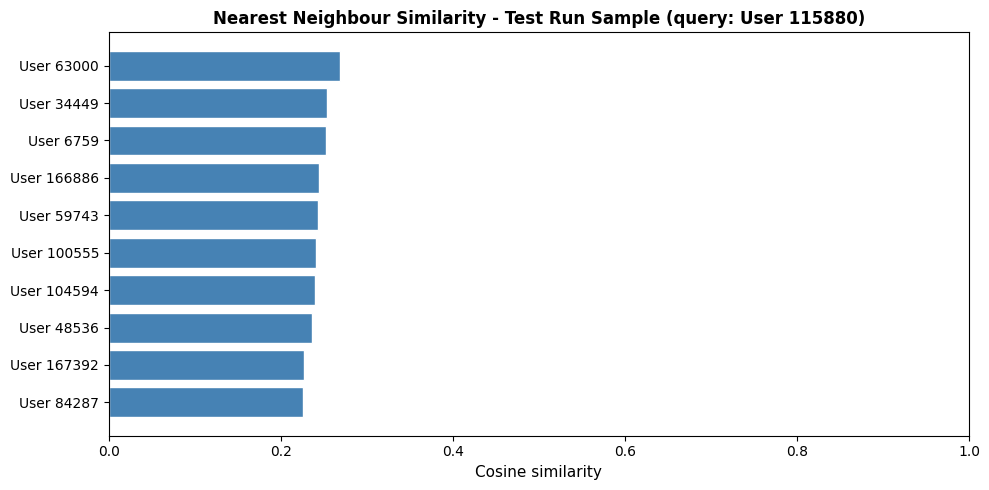

Step 7 - Content profile for User 115880 - top 10 similar products:
   1. similarity=0.5029  Unsweetened Almond Milk
   2. similarity=0.5010  Organic Unsweetened Almond Milk
   3. similarity=0.4962  Vanilla Unsweetened Almond Milk
   4. similarity=0.4936  Organic Coconut Milk
   5. similarity=0.4865  Organic Currants
   6. similarity=0.4865  Organic Yams
   7. similarity=0.4862  Organic Lite Coconut Milk
   8. similarity=0.4842  Almond Breeze Almond & Coconut Milk Blend
   9. similarity=0.4836  Toasted Coconut Almondmilk Blend
  10. similarity=0.4716  Pure Unsweetened Cashewmilk

Step 8 - All test artefacts written and deserialised successfully.
Test run complete. All temporary files deleted. No checkpoint written. Safe to proceed with the full pipeline.


In [6]:
RUN_TEST = True

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    import random
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    TEST_OUTPUT_DIR = OUTPUT_DIR / 'test_run_tmp'
    TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    print('=' * 60)
    print('  PREPROCESSING PIPELINE - TEST RUN (2,000 users)')
    print('=' * 60)
    print()

    # -- Step 1: Sample 2,000 users -------------------------------------------
    # Take a random subset of users to run a fast end-to-end smoke test.
    all_user_ids  = orders['user_id'].unique().tolist()
    sampled_users = set(random.sample(all_user_ids, min(2000, len(all_user_ids))))

    # Keep only orders belonging to the sampled users.
    t_orders      = orders[orders['user_id'].isin(sampled_users)].copy()
    # Restrict prior interactions to orders in the sampled prior set.
    t_order_prior = order_prior[order_prior['order_id'].isin(
        set(t_orders[t_orders['eval_set'] == 'prior']['order_id']))]
    # Restrict train interactions to orders in the sampled train set.
    t_order_train = order_train[order_train['order_id'].isin(
        set(t_orders[t_orders['eval_set'] == 'train']['order_id']))]

    print(f'Step 1 - Sampled {len(sampled_users):,} users')
    print(f'  Prior order rows : {len(t_order_prior):,}')
    print(f'  Train order rows : {len(t_order_train):,}')
    print()

    # -- Step 2: Apply all filters (identical to full pipeline) ---------------
    # Department filter: remove non-food products.
    t_products, dropped_dept_ids, dropped_depts = filter_non_food(products, departments)
    print('Step 2a - Department filter')
    print(f'  Dropped: {list(dropped_depts["department"])}')
    print(f'  Products remaining : {len(t_products):,}')

    # User filter: keep only users with enough prior orders.
    kept_users = filter_users_by_order_count(t_orders, MIN_USER_ORDERS)
    print(f'Step 2b - User filter (>= {MIN_USER_ORDERS} prior orders)')
    print(f'  Users remaining : {len(kept_users):,}')

    # Attach user_id to each prior order row so we can filter by user.
    t_merged = t_order_prior.merge(
        t_orders[['order_id', 'user_id']], on='order_id', how='left'
    )
    # Keep only rows belonging to users and food products that passed the filters.
    t_merged = t_merged[
        t_merged['user_id'].isin(kept_users) &
        t_merged['product_id'].isin(set(t_products['product_id']))
    ]
    print(f'  Prior rows after user + dept filter: {len(t_merged):,}')

    # Product filter: remove products with too few purchases in the sample.
    kept_product_ids = filter_products_by_purchase_count(t_merged, MIN_PRODUCT_PURCHASES)
    t_merged   = t_merged[t_merged['product_id'].isin(kept_product_ids)]
    t_products = t_products[t_products['product_id'].isin(kept_product_ids)].copy()
    print(f'Step 2c - Product filter (>= {MIN_PRODUCT_PURCHASES} purchases)')
    print(f'  Products remaining  : {len(t_products):,}')
    print(f'  Prior rows remaining: {len(t_merged):,}')

    # Remove users who lost all products during the product filter step.
    kept_users = kept_users & set(t_merged['user_id'].unique())
    t_merged   = t_merged[t_merged['user_id'].isin(kept_users)]
    print(f'  Final users : {len(kept_users):,}')
    print()

    # -- Step 3: Build user-item matrix ----------------------------------------
    # Count how many times each user bought each product.
    purchase_counts = (
        t_merged.groupby(['user_id', 'product_id'])
        .size().reset_index(name='count')
    )
    t_user_to_idx, t_product_to_idx = build_index_mappings(
        kept_users, set(t_products['product_id'])
    )
    t_matrix      = build_sparse_matrix(purchase_counts, t_user_to_idx, t_product_to_idx)
    # L2-normalise for cosine similarity via dot product.
    t_matrix_norm = sp.csr_matrix(normalize(t_matrix, norm='l2'))
    n_cells   = t_matrix.shape[0] * t_matrix.shape[1]
    sparsity  = (1.0 - t_matrix.nnz / n_cells) * 100
    print('Step 3 - User-item matrix')
    print(f'  Shape    : {t_matrix.shape}')
    print(f'  Non-zeros: {t_matrix.nnz:,}')
    print(f'  Sparsity : {sparsity:.4f}%')
    print()

    # -- Step 4: Build TF-IDF matrix -------------------------------------------
    # Attach aisle and department names so build_tfidf_text has all required columns.
    t_products_full = (
        t_products
        .merge(aisles,      on='aisle_id',      how='left')
        .merge(departments, on='department_id', how='left')
    )
    t_products_full['tfidf_text'] = build_tfidf_text(t_products_full)
    # Fit the vectoriser on this sample's product texts.
    t_vectoriser = fit_tfidf_vectoriser(t_products_full['tfidf_text'])
    # Transform each product into a TF-IDF sparse vector.
    t_tfidf      = sp.csr_matrix(t_vectoriser.transform(t_products_full['tfidf_text']))
    print('Step 4 - TF-IDF matrix')
    print(f'  Product TF-IDF shape : {t_tfidf.shape}')
    print(f'  Vocabulary size      : {len(t_vectoriser.vocabulary_):,}')
    print()

    # -- Step 5: User content profiles and NearestNeighbors -------------------
    t_user_profiles      = build_user_content_profiles(t_matrix, t_tfidf)
    # L2-normalise profiles for cosine-similarity comparisons at inference.
    t_user_profiles_norm = sp.csr_matrix(normalize(t_user_profiles, norm='l2'))
    t_knn                = fit_knn_model(t_matrix_norm)

    # Pick 3 random users and retrieve their 10 nearest neighbours.
    test_user_ids    = random.sample(sorted(kept_users), min(3, len(kept_users)))
    idx_list         = [t_user_to_idx[u] for u in test_user_ids]
    # Stack the selected user rows into a query matrix.
    query_rows       = t_matrix_norm[idx_list]
    # n_neighbors=11 because the query user itself is always returned as neighbour 0.
    distances, indices = t_knn.kneighbors(query_rows, n_neighbors=11)
    # Build the reverse mapping from integer index back to user_id.
    idx_to_user      = {v: k for k, v in t_user_to_idx.items()}

    print('Step 5 - NearestNeighbors fitted. Top 10 neighbours for 3 random users:')
    for qi, uid in enumerate(test_user_ids):
        print(f'  User {uid}:')
        for rank, (dist, nidx) in enumerate(
            zip(distances[qi][1:], indices[qi][1:]), start=1
        ):
            # Convert cosine distance to similarity (1 - distance).
            sim = 1.0 - dist
            print(f'    {rank:>2}. User {idx_to_user[nidx]}  similarity={sim:.4f}')
    print()

    # -- Step 6: Visualisation -------------------------------------------------
    viz_uid        = test_user_ids[0]
    # Skip index 0 (the query user itself) when collecting neighbours.
    neighbour_uids = [idx_to_user[nidx] for nidx in indices[0][1:11]]
    sim_scores     = [1.0 - d for d in distances[0][1:11]]

    # Plot a horizontal bar chart of similarity scores for the first test user.
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([f'User {u}' for u in neighbour_uids], sim_scores,
            color='steelblue', edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Cosine similarity', fontsize=11)
    ax.set_title(
        f'Nearest Neighbour Similarity - Test Run Sample (query: User {viz_uid})',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

    # -- Step 7: Content-based profile check ----------------------------------
    content_uid        = test_user_ids[0]
    content_uidx       = t_user_to_idx[content_uid]
    # Retrieve the normalised content profile row for this user.
    profile_vec        = t_user_profiles_norm[content_uidx]
    # L2-normalise product vectors so similarity equals dot product.
    product_tfidf_norm = sp.csr_matrix(normalize(t_tfidf, norm='l2'))
    # Dot product of the user profile with every product vector gives cosine similarities.
    sims               = profile_vec.dot(product_tfidf_norm.T).toarray().flatten()
    # Get indices of the top 10 most similar products in descending order.
    top10_idx          = np.argsort(sims)[::-1][:10]
    # Build reverse mappings to look up product IDs and names.
    idx_to_product     = {v: k for k, v in t_product_to_idx.items()}
    pid_to_name        = products.set_index('product_id')['product_name'].to_dict()

    print(f'Step 7 - Content profile for User {content_uid} - top 10 similar products:')
    for rank, pidx in enumerate(top10_idx, start=1):
        pid  = idx_to_product[pidx]
        name = pid_to_name.get(pid, 'unknown')
        print(f'  {rank:>2}. similarity={sims[pidx]:.4f}  {name}')
    print()

    # -- Step 8: Write artefacts, verify, then delete temp directory ----------
    # Serialise all artefacts to the temp directory to test the I/O round-trip.
    sp.save_npz(TEST_OUTPUT_DIR / 'user_item_matrix.npz',            t_matrix)
    sp.save_npz(TEST_OUTPUT_DIR / 'user_item_matrix_normalised.npz', t_matrix_norm)
    sp.save_npz(TEST_OUTPUT_DIR / 'product_tfidf_matrix.npz',        t_tfidf)
    sp.save_npz(TEST_OUTPUT_DIR / 'user_content_profiles.npz',            t_user_profiles)
    sp.save_npz(TEST_OUTPUT_DIR / 'user_content_profiles_normalised.npz', t_user_profiles_norm)
    joblib.dump(t_knn,        TEST_OUTPUT_DIR / 'knn_model.joblib')
    joblib.dump(t_vectoriser, TEST_OUTPUT_DIR / 'tfidf_vectoriser.joblib')
    with open(TEST_OUTPUT_DIR / 'product_index.json', 'w') as fh:
        json.dump({str(k): v for k, v in t_product_to_idx.items()}, fh)
    with open(TEST_OUTPUT_DIR / 'user_index.json', 'w') as fh:
        json.dump({str(k): v for k, v in t_user_to_idx.items()}, fh)

    # Reload each file and assert it matches the in-memory object.
    _cm = sp.load_npz(TEST_OUTPUT_DIR / 'user_item_matrix.npz')
    _cn = sp.load_npz(TEST_OUTPUT_DIR / 'user_item_matrix_normalised.npz')
    _ct  = sp.load_npz(TEST_OUTPUT_DIR / 'product_tfidf_matrix.npz')
    _cup = sp.load_npz(TEST_OUTPUT_DIR / 'user_content_profiles_normalised.npz')
    _ck  = joblib.load(TEST_OUTPUT_DIR / 'knn_model.joblib')
    _cv = joblib.load(TEST_OUTPUT_DIR / 'tfidf_vectoriser.joblib')
    assert _cm.shape == t_matrix.shape
    assert _cn.shape == t_matrix_norm.shape
    assert _ct.shape  == t_tfidf.shape
    assert _cup.shape == t_user_profiles_norm.shape
    # Confirm the KNN model and vectoriser were deserialised with their key attributes intact.
    assert hasattr(_ck, 'kneighbors')
    assert hasattr(_cv, 'vocabulary_')
    print('Step 8 - All test artefacts written and deserialised successfully.')

    # Delete the temporary directory; no permanent files should remain.
    shutil.rmtree(TEST_OUTPUT_DIR)
    print('Test run complete. All temporary files deleted.',
          'No checkpoint written. Safe to proceed with the full pipeline.')

## Section 5 - Filter Departments, Users, and Products

Applies the three filters in sequence: non-food department removal, minimum user order count, and minimum product purchase count. Saves the filtered prior interactions, train interactions, and product list as parquet files.

In [7]:
if reached_stage(CURRENT_STAGE, 'filtered'):
    print(f'Section 5 skipped: filtering already complete (stage={CURRENT_STAGE}).')
    # Reload filtered files from disk rather than re-running the pipeline.
    filtered_prior    = pd.read_parquet(OUTPUT_DIR / 'filtered_prior.parquet')
    filtered_train    = pd.read_parquet(OUTPUT_DIR / 'filtered_train.parquet')
    filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products.parquet')
else:
    # -- Step 1: Department filter --------------------------------------------
    filtered_products, dropped_dept_ids, dropped_depts = filter_non_food(
        products, departments
    )
    print('Step 1 - Non-food department filter')
    print('  Dropped departments:')
    for _, row in dropped_depts.iterrows():
        print(f'    id={row["department_id"]:>3}  {row["department"]}')
    print(f'  Products before filter : {len(products):,}')
    print(f'  Products after filter  : {len(filtered_products):,}')
    print(f'  Products dropped       : {len(products) - len(filtered_products):,}')
    print()

    # -- Step 2: User filter --------------------------------------------------
    kept_user_ids   = filter_users_by_order_count(orders, MIN_USER_ORDERS)
    n_dropped_users = orders['user_id'].nunique() - len(kept_user_ids)
    print(f'Step 2 - User filter (>= {MIN_USER_ORDERS} prior orders)')
    print(f'  Users before filter : {orders["user_id"].nunique():,}')
    print(f'  Users after filter  : {len(kept_user_ids):,}')
    print(f'  Users dropped       : {n_dropped_users:,}')
    print()

    # -- Step 3: Merge prior orders and apply user + dept filters -------------
    # Attach user_id to each prior order row to enable user-level filtering.
    merged = order_prior.merge(
        orders[['order_id', 'user_id']], on='order_id', how='left'
    )
    # Remove rows for users or products that did not pass their respective filters.
    merged = merged[
        merged['user_id'].isin(kept_user_ids) &
        merged['product_id'].isin(set(filtered_products['product_id']))
    ]
    print(f'Step 3 - Merged prior rows (user + dept filter applied): {len(merged):,}')
    print()

    # -- Step 4: Product filter -----------------------------------------------
    kept_product_ids = filter_products_by_purchase_count(merged, MIN_PRODUCT_PURCHASES)
    n_dropped_prods  = len(filtered_products) - len(kept_product_ids)
    # Remove products that did not reach the minimum purchase count.
    filtered_products = filtered_products[
        filtered_products['product_id'].isin(kept_product_ids)
    ].copy().reset_index(drop=True)
    merged = merged[merged['product_id'].isin(kept_product_ids)]
    print(f'Step 4 - Product filter (>= {MIN_PRODUCT_PURCHASES} purchases)')
    print(f'  Products after filter  : {len(filtered_products):,}')
    print(f'  Products dropped       : {n_dropped_prods:,}')
    print(f'  Prior rows remaining   : {len(merged):,}')
    print()

    # -- Step 5: Final consistency check --------------------------------------
    # Some users may have had all their products removed; re-derive the user set.
    users_with_purchases = set(merged['user_id'].unique())
    lost_users           = len(kept_user_ids) - len(users_with_purchases)
    kept_user_ids        = users_with_purchases
    filtered_prior       = merged.copy().reset_index(drop=True)
    print('Step 5 - Final consistency check')
    print(f'  Users removed by product filter : {lost_users:,}')
    print(f'  Final unique users              : {filtered_prior["user_id"].nunique():,}')
    print(f'  Final unique products           : {filtered_prior["product_id"].nunique():,}')
    print(f'  Final prior line items          : {len(filtered_prior):,}')
    print()

    # -- Step 6: Filter train set ---------------------------------------------
    final_user_ids    = set(filtered_prior['user_id'].unique())
    final_product_ids = set(filtered_prior['product_id'].unique())
    # Keep only train rows for users and products that survived the prior filtering.
    filtered_train = order_train[
        order_train['order_id'].isin(
            set(orders[orders['user_id'].isin(final_user_ids)]['order_id'])
        ) &
        order_train['product_id'].isin(final_product_ids)
    ].copy().reset_index(drop=True)
    print(f'Step 6 - Filtered train set rows : {len(filtered_train):,}')
    print()

    # Write filtered data to parquet for use by downstream sections.
    filtered_prior.to_parquet(   OUTPUT_DIR / 'filtered_prior.parquet',    index=False)
    filtered_train.to_parquet(   OUTPUT_DIR / 'filtered_train.parquet',    index=False)
    filtered_products.to_parquet(OUTPUT_DIR / 'filtered_products.parquet', index=False)

    # Save a summary of the final dataset dimensions for reference.
    filter_summary = {
        'n_users'     : int(filtered_prior['user_id'].nunique()),
        'n_products'  : int(filtered_prior['product_id'].nunique()),
        'n_prior_rows': int(len(filtered_prior)),
    }
    with open(OUTPUT_DIR / 'filter_summary.json', 'w', encoding='utf-8') as fh:
        json.dump(filter_summary, fh, indent=2)
    print('Saved: filtered_prior.parquet, filtered_train.parquet,',
          'filtered_products.parquet, filter_summary.json')

    save_checkpoint('filtered', filter_summary)
    CURRENT_STAGE = 'filtered'

Step 1 - Non-food department filter
  Dropped departments:
    id=  2  other
    id=  5  alcohol
    id=  8  pets
    id= 11  personal care
    id= 17  household
    id= 18  babies
    id= 21  missing
  Products before filter : 49,688
  Products after filter  : 35,127
  Products dropped       : 14,561

Step 2 - User filter (>= 5 prior orders)
  Users before filter : 206,209
  Users after filter  : 162,633
  Users dropped       : 43,576

Step 3 - Merged prior rows (user + dept filter applied): 29,121,947

Step 4 - Product filter (>= 10 purchases)
  Products after filter  : 30,939
  Products dropped       : 4,188
  Prior rows remaining   : 29,098,485

Step 5 - Final consistency check
  Users removed by product filter : 89
  Final unique users              : 162,544
  Final unique products           : 30,939
  Final prior line items          : 29,098,485

Step 6 - Filtered train set rows : 1,035,634

Saved: filtered_prior.parquet, filtered_train.parquet, filtered_products.parquet, filter_

## Section 6 - Build the User-Item Matrix

Builds the sparse user-item matrix of raw purchase counts and an L2-normalised version for cosine similarity. Both are saved as `.npz` files along with the user and product index mappings.

In [8]:
if past_stage(CURRENT_STAGE, 'matrix_built'):
    print(f'Section 6 skipped: matrix already built (stage={CURRENT_STAGE}).')
    # Reload matrix and index mappings from disk.
    user_item_matrix      = sp.load_npz(OUTPUT_DIR / 'user_item_matrix.npz')
    user_item_matrix_norm = sp.load_npz(OUTPUT_DIR / 'user_item_matrix_normalised.npz')
    # Keys in the JSON are strings; cast back to int for consistent lookup.
    with open(OUTPUT_DIR / 'user_index.json',    'r') as fh:
        user_to_idx    = {int(k): v for k, v in json.load(fh).items()}
    with open(OUTPUT_DIR / 'product_index.json', 'r') as fh:
        product_to_idx = {int(k): v for k, v in json.load(fh).items()}
else:
    if 'filtered_prior' not in dir():
        filtered_prior    = pd.read_parquet(OUTPUT_DIR / 'filtered_prior.parquet')
        filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products.parquet')

    # -- Step 1: Index mappings -----------------------------------------------
    user_ids    = set(filtered_prior['user_id'].unique())
    product_ids = set(filtered_prior['product_id'].unique())
    user_to_idx, product_to_idx = build_index_mappings(user_ids, product_ids)

    # Persist index mappings so the inference notebook can decode matrix rows/columns.
    with open(OUTPUT_DIR / 'user_index.json', 'w', encoding='utf-8') as fh:
        json.dump({str(k): v for k, v in user_to_idx.items()}, fh)
    with open(OUTPUT_DIR / 'product_index.json', 'w', encoding='utf-8') as fh:
        json.dump({str(k): v for k, v in product_to_idx.items()}, fh)
    print('Step 1 - Index mappings built')
    print(f'  Users    : {len(user_to_idx):,}')
    print(f'  Products : {len(product_to_idx):,}')
    print()

    # -- Step 2: Purchase counts ----------------------------------------------
    # Aggregate all prior interactions to a single (user, product) count per pair.
    purchase_counts = (
        filtered_prior
        .groupby(['user_id', 'product_id'])
        .size()
        .reset_index(name='count')
    )
    print(f'Step 2 - Unique (user, product) pairs: {len(purchase_counts):,}')
    print()

    # -- Step 3: Sparse CSR matrix --------------------------------------------
    user_item_matrix = build_sparse_matrix(purchase_counts, user_to_idx, product_to_idx)
    n_cells  = user_item_matrix.shape[0] * user_item_matrix.shape[1]
    sparsity = (1.0 - user_item_matrix.nnz / n_cells) * 100
    print('Step 3 - User-item matrix (raw purchase counts)')
    print(f'  Shape    : {user_item_matrix.shape}')
    print(f'  Non-zeros: {user_item_matrix.nnz:,}')
    print(f'  Sparsity : {sparsity:.4f}%')
    print()

    # -- Step 4: L2 normalise for k-NN ----------------------------------------
    user_item_matrix_norm = sp.csr_matrix(normalize(user_item_matrix, norm='l2'))
    print('Step 4 - L2 normalisation applied.')
    print('  Cosine similarity of L2-normalised vectors equals their dot product,')
    print('  which brute-force NearestNeighbors computes efficiently via BLAS.')
    print()

    sp.save_npz(OUTPUT_DIR / 'user_item_matrix.npz',            user_item_matrix)
    sp.save_npz(OUTPUT_DIR / 'user_item_matrix_normalised.npz', user_item_matrix_norm)
    print('Saved: user_item_matrix.npz, user_item_matrix_normalised.npz')

    save_checkpoint('matrix_built')
    CURRENT_STAGE = 'matrix_built'

Step 1 - Index mappings built
  Users    : 162,544
  Products : 30,939

Step 2 - Unique (user, product) pairs: 11,175,459

Step 3 - User-item matrix (raw purchase counts)
  Shape    : (162544, 30939)
  Non-zeros: 11,175,459
  Sparsity : 99.7778%

Step 4 - L2 normalisation applied.
  Cosine similarity of L2-normalised vectors equals their dot product,
  which brute-force NearestNeighbors computes efficiently via BLAS.

Saved: user_item_matrix.npz, user_item_matrix_normalised.npz
Checkpoint saved: stage=matrix_built  timestamp=2026-04-10T14:20:36.749083


## Section 7 - Build the TF-IDF Content Matrix

Constructs product TF-IDF vectors from product name, aisle, and department, then builds frequency-weighted user content profiles as the purchase-count-weighted average of each user's product vectors.

In [9]:
if past_stage(CURRENT_STAGE, 'tfidf_built'):
    print(f'Section 7 skipped: TF-IDF already built (stage={CURRENT_STAGE}).')
    # Reload from disk to make these variables available for downstream sections.
    product_tfidf_matrix       = sp.load_npz(OUTPUT_DIR / 'product_tfidf_matrix.npz')
    user_content_profiles      = sp.load_npz(OUTPUT_DIR / 'user_content_profiles.npz')
    user_content_profiles_norm = sp.load_npz(
        OUTPUT_DIR / 'user_content_profiles_normalised.npz')
    tfidf_vectoriser = joblib.load(OUTPUT_DIR / 'tfidf_vectoriser.joblib')
else:
    if 'filtered_products' not in dir():
        filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products.parquet')
    if 'user_item_matrix' not in dir():
        user_item_matrix = sp.load_npz(OUTPUT_DIR / 'user_item_matrix.npz')

    # -- Steps 1 & 2: Build tfidf_text via shared function --------------------
    # Attach aisle and department names so the shared function has all required columns.
    products_full = (
        filtered_products
        .merge(aisles,      on='aisle_id',      how='left')
        .merge(departments, on='department_id', how='left')
    )
    products_full['tfidf_text'] = build_tfidf_text(products_full)

    print('Step 1 - TF-IDF text field constructed. 10 random examples:')
    for _, row in products_full[['product_name', 'tfidf_text']].sample(
            10, random_state=RANDOM_SEED).iterrows():
        print(f'  [{row["product_name"]}]')
        print(f'   -> {row["tfidf_text"]}')
    print()

    # -- Step 3: Fit vectoriser -----------------------------------------------
    tfidf_vectoriser = fit_tfidf_vectoriser(products_full['tfidf_text'])
    print('Step 3 - TF-IDF vectoriser fitted')
    print(f'  Vocabulary size : {len(tfidf_vectoriser.vocabulary_):,}')
    print(f'  ngram_range     : {tfidf_vectoriser.ngram_range}')
    print(f'  sublinear_tf    : {tfidf_vectoriser.sublinear_tf}')
    print(f'  min_df          : {tfidf_vectoriser.min_df}')
    print()
    joblib.dump(tfidf_vectoriser, OUTPUT_DIR / 'tfidf_vectoriser.joblib')

    # -- Step 4: Transform products -------------------------------------------
    # Apply the fitted vectoriser to produce a sparse TF-IDF matrix for all products.
    product_tfidf_matrix = sp.csr_matrix(
        tfidf_vectoriser.transform(products_full['tfidf_text'])
    )
    print(f'Step 4 - Product TF-IDF matrix shape: {product_tfidf_matrix.shape}')
    sp.save_npz(OUTPUT_DIR / 'product_tfidf_matrix.npz', product_tfidf_matrix)
    print()

    # -- Step 5: Frequency-weighted user content profiles ---------------------
    user_content_profiles      = build_user_content_profiles(
        user_item_matrix, product_tfidf_matrix
    )
    # L2-normalise so content-based similarity can be computed as a dot product.
    user_content_profiles_norm = sp.csr_matrix(
        normalize(user_content_profiles, norm='l2')
    )
    print(f'Step 5 - User content profiles shape: {user_content_profiles.shape}')
    sp.save_npz(OUTPUT_DIR / 'user_content_profiles.npz',            user_content_profiles)
    sp.save_npz(OUTPUT_DIR / 'user_content_profiles_normalised.npz', user_content_profiles_norm)
    print('Saved: product_tfidf_matrix.npz, user_content_profiles.npz,',
          'user_content_profiles_normalised.npz, tfidf_vectoriser.joblib')

    save_checkpoint('tfidf_built')
    CURRENT_STAGE = 'tfidf_built'

Step 1 - TF-IDF text field constructed. 10 random examples:
  [Easter All Natural Sour Jelly Beans]
   -> easter all natural sour jelly beans candy chocolate snacks
  [Organic Spirulina Dream Bar]
   -> organic spirulina dream bar energy granola bars snacks
  [Instant Rolled Oats Whole Grain]
   -> instant rolled oats whole grain hot cereal pancake mixes breakfast
  [Multiseed Spelt Flatbread]
   -> multiseed spelt flatbread crackers snacks
  [Coffee, Ground, House Blend, Medium Roast]
   -> coffee, ground, house blend, medium roast coffee beverages
  [Fig Bars]
   -> fig bars cookies cakes snacks
  [Essential Orange-Orange Vitamin Water Drink]
   -> essential orange-orange vitamin water drink energy sports drinks beverages
  [Original Crispy Apple Chips]
   -> original crispy apple chips chips pretzels snacks
  [Simply 100 Mango Passion Fruit Blended Non-Fat Greek Yogurt]
   -> simply 100 mango passion fruit blended non-fat greek yogurt yogurt dairy eggs
  [SportsDrink, Orange Flavore

## Section 8 - Fit the NearestNeighbors Model

Fits the NearestNeighbors model on the L2-normalised user-item matrix. Brute-force search is chosen because tree methods provide no pruning benefit at tens of thousands of product dimensions.

In [10]:
if past_stage(CURRENT_STAGE, 'knn_fitted'):
    print(f'Section 8 skipped: NearestNeighbors already fitted (stage={CURRENT_STAGE}).')
    knn_model = joblib.load(OUTPUT_DIR / 'knn_model.joblib')
else:
    if 'user_item_matrix_norm' not in dir():
        # Reload the normalised matrix if this section is being run in isolation.
        user_item_matrix_norm = sp.load_npz(
            OUTPUT_DIR / 'user_item_matrix_normalised.npz'
        )

    # Fit the NearestNeighbors model on the normalised user-item matrix.
    knn_model = fit_knn_model(user_item_matrix_norm)

    print('NearestNeighbors model fitted.')
    print(f'  metric    : {knn_model.metric}')
    print(f'  algorithm : {knn_model.algorithm}')
    print(f'  n_jobs    : {knn_model.n_jobs}')
    print(f'  Training data shape: {user_item_matrix_norm.shape}')
    print()
    print(f'  The matrix has {user_item_matrix_norm.shape[1]:,} product dimensions.')
    print('  Tree-based methods provide no pruning benefit at this dimensionality.')
    print('  Brute-force is executed efficiently via BLAS dot-product routines.')

    joblib.dump(knn_model, OUTPUT_DIR / 'knn_model.joblib')
    print('Saved: knn_model.joblib')

    save_checkpoint('knn_fitted')
    CURRENT_STAGE = 'knn_fitted'

NearestNeighbors model fitted.
  metric    : cosine
  algorithm : brute
  n_jobs    : -1
  Training data shape: (162544, 30939)

  The matrix has 30,939 product dimensions.
  Tree-based methods provide no pruning benefit at this dimensionality.
  Brute-force is executed efficiently via BLAS dot-product routines.
Saved: knn_model.joblib
Checkpoint saved: stage=knn_fitted  timestamp=2026-04-10T14:23:23.126409


## Section 9 - Global Popularity Index

Builds a global product popularity ranking by total purchase count. Used as a cold-start fallback when a user has too few interactions to generate meaningful nearest neighbours.

In [11]:
if reached_stage(CURRENT_STAGE, 'complete'):
    print('Section 9 skipped: pipeline already complete.')
else:
    if 'filtered_prior' not in dir():
        filtered_prior = pd.read_parquet(OUTPUT_DIR / 'filtered_prior.parquet')

    # Count total purchases per product across all users in the filtered prior set.
    popularity = (
        filtered_prior
        .groupby('product_id')
        .size()
        .reset_index(name='purchase_count')
        .sort_values('purchase_count', ascending=False)
    )

    # Build a name lookup so we can print product names in the summary.
    pid_to_name = products.set_index('product_id')['product_name'].to_dict()

    print('Top 20 most popular products (globally):')
    print('-' * 60)
    for rank, (_, row) in enumerate(popularity.head(20).iterrows(), start=1):
        name = pid_to_name.get(row['product_id'], 'unknown')
        print(f'  {rank:>2}.  {row["purchase_count"]:>8,}  {name}')
    print()

    # Store the popularity ranking as an ordered list of product IDs.
    global_popularity_list = [int(pid) for pid in popularity['product_id'].tolist()]
    with open(OUTPUT_DIR / 'global_popularity.json', 'w', encoding='utf-8') as fh:
        json.dump(global_popularity_list, fh)
    print(f'Saved: global_popularity.json  ({len(global_popularity_list):,} products)')

    save_checkpoint('complete')
    CURRENT_STAGE = 'complete'

Top 20 most popular products (globally):
------------------------------------------------------------
   1.   453,164  Banana
   2.   366,403  Bag of Organic Bananas
   3.   255,988  Organic Strawberries
   4.   231,772  Organic Baby Spinach
   5.   206,799  Organic Hass Avocado
   6.   168,267  Organic Avocado
   7.   145,397  Large Lemon
   8.   136,330  Strawberries
   9.   134,751  Limes
  10.   133,514  Organic Whole Milk
  11.   132,945  Organic Raspberries
  12.   109,219  Organic Yellow Onion
  13.   105,639  Organic Garlic
  14.   100,664  Organic Zucchini
  15.    95,637  Organic Blueberries
  16.    92,612  Cucumber Kirby
  17.    85,941  Organic Fuji Apple
  18.    84,608  Organic Lemon
  19.    82,349  Apple Honeycrisp Organic
  20.    80,756  Organic Grape Tomatoes

Saved: global_popularity.json  (30,939 products)
Checkpoint saved: stage=complete  timestamp=2026-04-10T14:23:32.130581


## Section 10 - Verification and Summary

Loads every output file and prints key properties to confirm each was written correctly.

In [12]:
print('=' * 64)
print('  OUTPUT FILE VERIFICATION')
print('=' * 64)
print()

verification_results = []

def _verify(label, path, check_fn):
    # Attempt to load the file and run check_fn; record the result.
    exists = path.exists()
    status = 'OK'
    detail = ''
    if exists:
        try:
            detail = check_fn(path)
        except Exception as exc:
            status = 'ERROR'
            detail = str(exc)
    else:
        status = 'MISSING'
    verification_results.append((label, status, detail))
    print(f'  {label:<52} {status}')
    if detail:
        print(f'    {detail}')

# Each call loads the file, extracts key properties, and prints the result.
_verify('user_item_matrix.npz', OUTPUT_DIR / 'user_item_matrix.npz',
    lambda p: (lambda m: f'shape={m.shape}  nnz={m.nnz:,}')(sp.load_npz(p)))

_verify('user_item_matrix_normalised.npz',
    OUTPUT_DIR / 'user_item_matrix_normalised.npz',
    lambda p: (lambda m: f'shape={m.shape}  nnz={m.nnz:,}')(sp.load_npz(p)))

_verify('product_tfidf_matrix.npz', OUTPUT_DIR / 'product_tfidf_matrix.npz',
    lambda p: (lambda m: f'shape={m.shape}')(sp.load_npz(p)))

_verify('user_content_profiles.npz', OUTPUT_DIR / 'user_content_profiles.npz',
    lambda p: (lambda m: f'shape={m.shape}')(sp.load_npz(p)))

_verify('user_content_profiles_normalised.npz',
    OUTPUT_DIR / 'user_content_profiles_normalised.npz',
    lambda p: (lambda m: f'shape={m.shape}')(sp.load_npz(p)))

_verify('knn_model.joblib', OUTPUT_DIR / 'knn_model.joblib',
    lambda p: (lambda m: f'metric={m.metric}  algorithm={m.algorithm}')(joblib.load(p)))

_verify('tfidf_vectoriser.joblib', OUTPUT_DIR / 'tfidf_vectoriser.joblib',
    lambda p: (lambda v: f'vocabulary size={len(v.vocabulary_):,}')(joblib.load(p)))

_verify('product_index.json', OUTPUT_DIR / 'product_index.json',
    lambda p: (lambda d: f'{len(d):,} products')(json.load(open(p))))

_verify('user_index.json', OUTPUT_DIR / 'user_index.json',
    lambda p: (lambda d: f'{len(d):,} users')(json.load(open(p))))

_verify('global_popularity.json', OUTPUT_DIR / 'global_popularity.json',
    lambda p: (lambda d: f'{len(d):,} products  top5={d[:5]}')(json.load(open(p))))

_verify('filter_summary.json', OUTPUT_DIR / 'filter_summary.json',
    lambda p: '  '.join(f'{k}={v:,}' for k, v in json.load(open(p)).items()))

_verify('filtered_prior.parquet', OUTPUT_DIR / 'filtered_prior.parquet',
    lambda p: (lambda df: f'shape={df.shape}')(pd.read_parquet(p)))

_verify('filtered_train.parquet', OUTPUT_DIR / 'filtered_train.parquet',
    lambda p: (lambda df: f'shape={df.shape}')(pd.read_parquet(p)))

_verify('filtered_products.parquet', OUTPUT_DIR / 'filtered_products.parquet',
    lambda p: (lambda df: f'shape={df.shape}')(pd.read_parquet(p)))

print()
print('=' * 64)
n_ok      = sum(1 for _, s, _ in verification_results if s == 'OK')
n_missing = sum(1 for _, s, _ in verification_results if s == 'MISSING')
n_error   = sum(1 for _, s, _ in verification_results if s == 'ERROR')
print(f'  {n_ok} OK   {n_missing} MISSING   {n_error} ERROR')
print()
if n_missing == 0 and n_error == 0:
    print('Task 1A preprocessing complete. All artefacts verified.')
else:
    print('WARNING: some output files are missing or failed to load.')
    print('Re-run the relevant sections to regenerate missing artefacts.')
print('=' * 64)

  OUTPUT FILE VERIFICATION

  user_item_matrix.npz                                 OK
    shape=(162544, 30939)  nnz=11,175,459
  user_item_matrix_normalised.npz                      OK
    shape=(162544, 30939)  nnz=11,175,459
  product_tfidf_matrix.npz                             OK
    shape=(30939, 19531)
  user_content_profiles.npz                            OK
    shape=(162544, 19531)
  user_content_profiles_normalised.npz                 OK
    shape=(162544, 19531)
  knn_model.joblib                                     OK
    metric=cosine  algorithm=brute
  tfidf_vectoriser.joblib                              OK
    vocabulary size=19,531
  product_index.json                                   OK
    30,939 products
  user_index.json                                      OK
    162,544 users
  global_popularity.json                               OK
    30,939 products  top5=[24852, 13176, 21137, 21903, 47209]
  filter_summary.json                                  OK
    n_users